In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("Goal_Achievement_Dataset.csv")

In [4]:
df.info

<bound method DataFrame.info of      Plan_Granularity  Social_Support  Initial_Intensity  Feedback_Frequency  \
0                   2               0               44.8                   3   
1                   2               0               14.7                   9   
2                   5               0               45.8                   2   
3                   6               1               36.6                  12   
4                  10               1               35.1                  11   
..                ...             ...                ...                 ...   
195                 8               1               54.9                   5   
196                10               1               18.4                   3   
197                 8               1               28.2                  11   
198                 2               0               46.1                   6   
199                10               1               39.9                   0   

     Id

In [5]:
df.shape

(200, 12)

In [6]:
df.head()

,Plan_Granularity,Social_Support,Initial_Intensity,Feedback_Frequency,Identity_Congruence,External_Stressors,Goal_Specificity,Past_Success_Rate,Intrinsic_Motivation,Deadline_Presence,Obstacle_Anticipation,Goal_Achieved
0,2,0,44.8,3,4,3,2,0.68,9,0,1,1
1,2,0,14.7,9,1,9,4,0.72,9,1,0,1
2,5,0,45.8,2,7,6,5,0.16,6,0,0,1
3,6,1,36.6,12,1,8,9,0.12,7,0,1,0
4,10,1,35.1,11,2,1,4,0.77,2,0,0,1


In [7]:
df.describe()

,Plan_Granularity,Social_Support,Initial_Intensity,Feedback_Frequency,Identity_Congruence,External_Stressors,Goal_Specificity,Past_Success_Rate,Intrinsic_Motivation,Deadline_Presence,Obstacle_Anticipation,Goal_Achieved
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000
mean,5.445000,0.575000,31.563000,6.985000,5.485000,5.570000,5.380000,0.509200,5.400000,0.515000,0.54500,0.79000
std,2.908483,0.495584,16.779532,4.065392,2.881194,2.788184,2.915148,0.286378,2.844372,0.501029,0.49922,0.40833
min,1.000000,0.000000,1.500000,0.000000,1.000000,1.000000,1.000000,0.020000,1.000000,0.000000,0.00000,0.00000
25%,3.000000,0.000000,17.625000,3.750000,3.000000,3.000000,3.000000,0.247500,3.000000,0.000000,0.00000,1.00000
50%,5.000000,1.000000,32.550000,7.000000,6.000000,6.000000,5.000000,0.480000,5.000000,1.000000,1.00000,1.00000
75%,8.000000,1.000000,45.500000,10.000000,8.000000,8.000000,8.000000,0.770000,8.000000,1.000000,1.00000,1.00000
max,10.000000,1.000000,60.000000,14.000000,10.000000,10.000000,10.000000,1.000000,10.000000,1.000000,1.00000,1.00000


In [8]:
df.columns

Index(['Plan_Granularity', 'Social_Support', 'Initial_Intensity',
       'Feedback_Frequency', 'Identity_Congruence', 'External_Stressors',
       'Goal_Specificity', 'Past_Success_Rate', 'Intrinsic_Motivation',
       'Deadline_Presence', 'Obstacle_Anticipation', 'Goal_Achieved'],
      dtype='object')

In [9]:
# Remove duplicates
df = df.drop_duplicates()
df.shape

(200, 12)

In [10]:
# Check missing values
df.isnull().sum()

Plan_Granularity         0
Social_Support           0
Initial_Intensity        0
Feedback_Frequency       0
Identity_Congruence      0
External_Stressors       0
Goal_Specificity         0
Past_Success_Rate        0
Intrinsic_Motivation     0
Deadline_Presence        0
Obstacle_Anticipation    0
Goal_Achieved            0
dtype: int64

In [11]:
# Fill missing values — numeric with median, binary with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

df.isnull().sum()


Plan_Granularity         0
Social_Support           0
Initial_Intensity        0
Feedback_Frequency       0
Identity_Congruence      0
External_Stressors       0
Goal_Specificity         0
Past_Success_Rate        0
Intrinsic_Motivation     0
Deadline_Presence        0
Obstacle_Anticipation    0
Goal_Achieved            0
dtype: int64

In [12]:
# Fix data types for binary columns
df['Social_Support']        = df['Social_Support'].astype(int)
df['Deadline_Presence']     = df['Deadline_Presence'].astype(int)
df['Obstacle_Anticipation'] = df['Obstacle_Anticipation'].astype(int)
df['Goal_Achieved']         = df['Goal_Achieved'].astype(int)
df.dtypes

Plan_Granularity           int64
Social_Support             int64
Initial_Intensity        float64
Feedback_Frequency         int64
Identity_Congruence        int64
External_Stressors         int64
Goal_Specificity           int64
Past_Success_Rate        float64
Intrinsic_Motivation       int64
Deadline_Presence          int64
Obstacle_Anticipation      int64
Goal_Achieved              int64
dtype: object

In [13]:
# Outlier removal using IQR on continuous columns
continuous_cols = ['Initial_Intensity', 'Past_Success_Rate', 'Feedback_Frequency']

for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (200, 12)


In [14]:
# Clip scale features to valid range (1–10)
scale_cols = ['Plan_Granularity', 'Identity_Congruence',
              'External_Stressors', 'Goal_Specificity', 'Intrinsic_Motivation']
for col in scale_cols:
    df[col] = df[col].clip(1, 10)

df.head()

,Plan_Granularity,Social_Support,Initial_Intensity,Feedback_Frequency,Identity_Congruence,External_Stressors,Goal_Specificity,Past_Success_Rate,Intrinsic_Motivation,Deadline_Presence,Obstacle_Anticipation,Goal_Achieved
0,2,0,44.8,3,4,3,2,0.68,9,0,1,1
1,2,0,14.7,9,1,9,4,0.72,9,1,0,1
2,5,0,45.8,2,7,6,5,0.16,6,0,0,1
3,6,1,36.6,12,1,8,9,0.12,7,0,1,0
4,10,1,35.1,11,2,1,4,0.77,2,0,0,1


In [15]:
# Save cleaned dataset
df.to_csv("goal_achievement_cleaned.csv", index=False)

print("Final null check:")
print(df.isnull().sum())
print("\nFinal shape:", df.shape)
print("Target distribution:\n", df['Goal_Achieved'].value_counts())

Final null check:
Plan_Granularity         0
Social_Support           0
Initial_Intensity        0
Feedback_Frequency       0
Identity_Congruence      0
External_Stressors       0
Goal_Specificity         0
Past_Success_Rate        0
Intrinsic_Motivation     0
Deadline_Presence        0
Obstacle_Anticipation    0
Goal_Achieved            0
dtype: int64

Final shape: (200, 12)
Target distribution:
 Goal_Achieved
1    158
0     42
Name: count, dtype: int64


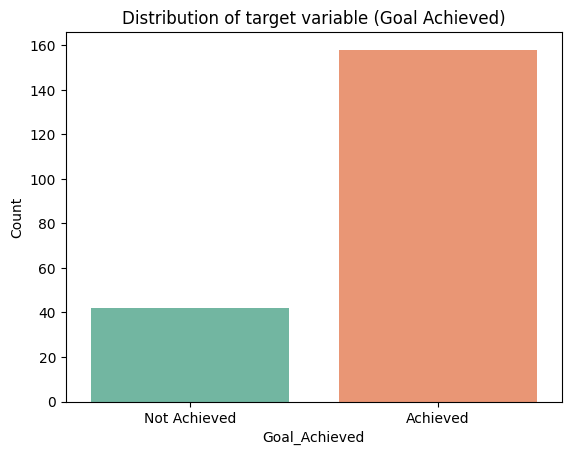

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target class distribution
plt.figure()
sns.countplot(x='Goal_Achieved', data=df, hue='Goal_Achieved', palette='Set2', legend=False)
plt.title("Distribution of target variable (Goal Achieved)")
plt.xticks([0, 1], ['Not Achieved', 'Achieved'])
plt.ylabel("Count")
plt.show()
# Insight: Shows class balance. If heavily imbalanced, consider SMOTE or class_weight='balanced'.

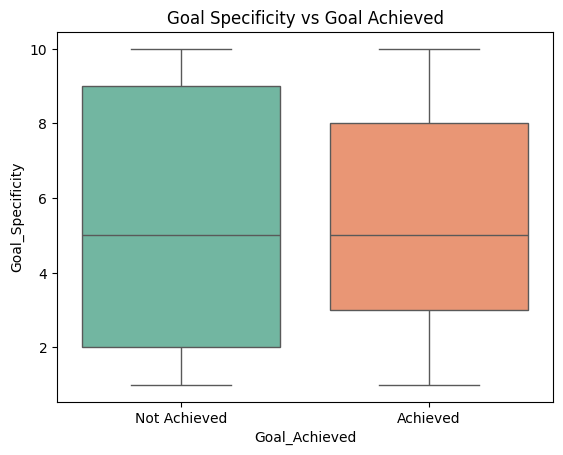

In [19]:
# Goal Specificity vs Goal Achieved
plt.figure()
sns.boxplot(x='Goal_Achieved', y='Goal_Specificity', data=df, hue='Goal_Achieved', palette='Set2', legend=False)
plt.title("Goal Specificity vs Goal Achieved")
plt.xticks([0, 1], ['Not Achieved', 'Achieved'])
plt.show()

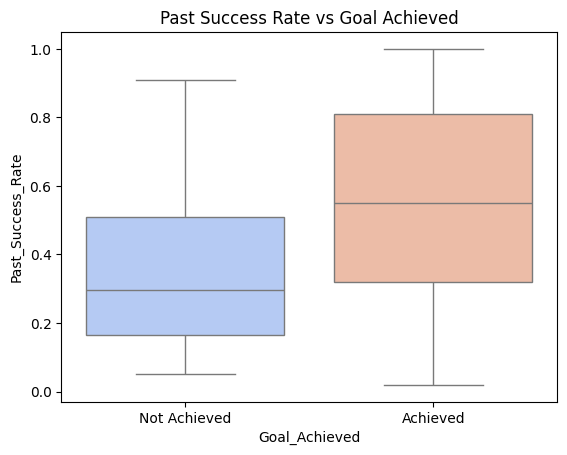

In [20]:
# Past Success Rate vs Goal Achieved
plt.figure()
sns.boxplot(x='Goal_Achieved', y='Past_Success_Rate', data=df, hue='Goal_Achieved', palette='coolwarm', legend=False)
plt.title("Past Success Rate vs Goal Achieved")
plt.xticks([0, 1], ['Not Achieved', 'Achieved'])
plt.show()

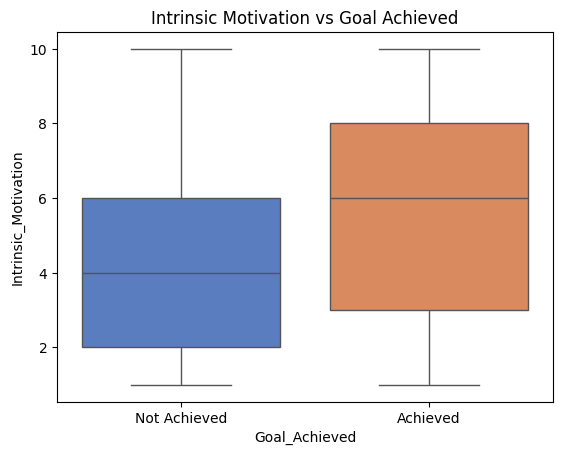

In [21]:
plt.figure()
sns.boxplot(x='Goal_Achieved', y='Intrinsic_Motivation', data=df, hue='Goal_Achieved', palette='muted', legend=False)
plt.title("Intrinsic Motivation vs Goal Achieved")
plt.xticks([0, 1], ['Not Achieved', 'Achieved'])
plt.show()

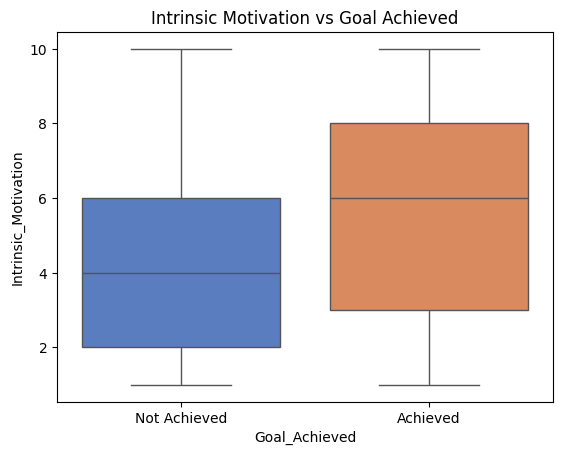

In [22]:
plt.figure()
sns.boxplot(x='Goal_Achieved', y='Intrinsic_Motivation', data=df, hue='Goal_Achieved', palette='muted', legend=False)
plt.title("Intrinsic Motivation vs Goal Achieved")
plt.xticks([0, 1], ['Not Achieved', 'Achieved'])
plt.show()

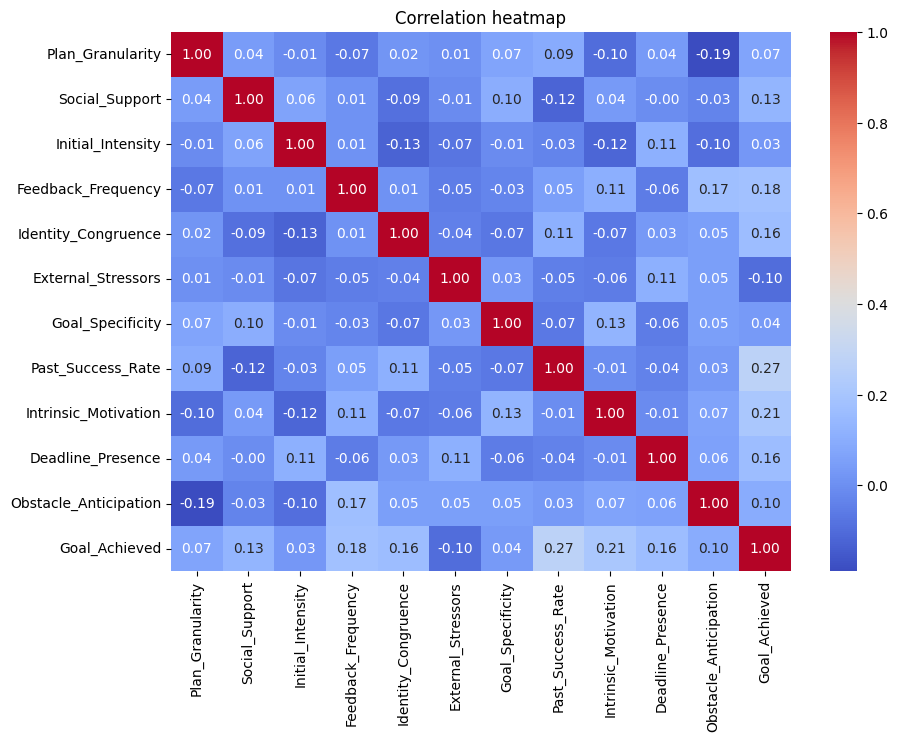

In [23]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation heatmap")
plt.show()
# Insight: Features near ±1 with Goal_Achieved are the strongest predictors.

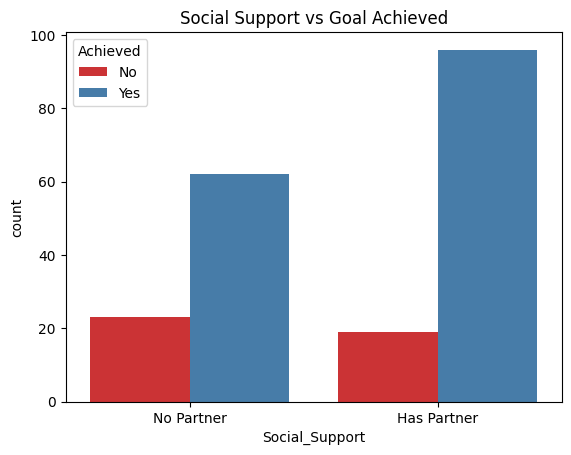

In [24]:
# Social Support vs Goal Achieved
plt.figure()
sns.countplot(x='Social_Support', hue='Goal_Achieved', data=df, palette='Set1')
plt.title("Social Support vs Goal Achieved")
plt.xticks([0, 1], ['No Partner', 'Has Partner'])
plt.legend(title='Achieved', labels=['No', 'Yes'])
plt.show()
# Insight: Accountability partners significantly boost success rate.


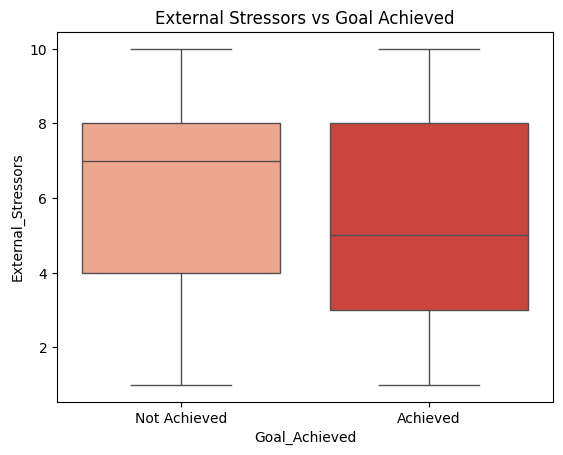

In [26]:
# External Stressors vs Goal Achieved
plt.figure()
sns.boxplot(x='Goal_Achieved', y='External_Stressors', data=df, hue='Goal_Achieved', palette='Reds', legend=False)
plt.title("External Stressors vs Goal Achieved")
plt.xticks([0, 1], ['Not Achieved', 'Achieved'])
plt.show()
# Insight: Higher stress consistently links to lower goal achievement.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                               confusion_matrix, roc_auc_score, roc_curve)

In [29]:
# Define features and target
X = df.drop('Goal_Achieved', axis=1)
y = df['Goal_Achieved']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (200, 11)
Target shape:   (200,)


In [30]:
# Train-test split (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training size:", X_train.shape)
print("Testing size: ", X_test.shape)

Training size: (160, 11)
Testing size:  (40, 11)


In [31]:
# Feature scaling — required for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [32]:
# Train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_sc, y_train)
print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [33]:
# Predictions and evaluation
y_pred_lr = lr_model.predict(X_test_sc)
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
roc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results:")
print(f"Accuracy : {acc_lr:.4f}")
print(f"ROC-AUC  : {roc_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Not Achieved', 'Achieved']))

Logistic Regression Results:
Accuracy : 0.8000
ROC-AUC  : 0.7852

              precision    recall  f1-score   support

Not Achieved       0.50      0.12      0.20         8
    Achieved       0.82      0.97      0.89        32

    accuracy                           0.80        40
   macro avg       0.66      0.55      0.54        40
weighted avg       0.75      0.80      0.75        40



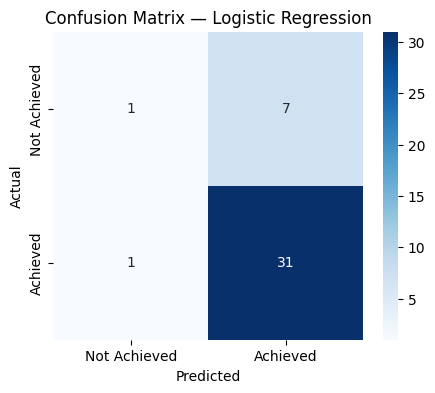

In [34]:
# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Not Achieved', 'Achieved'],
            yticklabels=['Not Achieved', 'Achieved'])
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [35]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [36]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


In [37]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
roc_dt = roc_auc_score(y_test, y_prob_dt)

print("Decision Tree Results:")
print(f"Accuracy : {acc_dt:.4f}")
print(f"ROC-AUC  : {roc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt,
      target_names=['Not Achieved', 'Achieved']))

Decision Tree Results:
Accuracy : 0.8000
ROC-AUC  : 0.5547

              precision    recall  f1-score   support

Not Achieved       0.50      0.12      0.20         8
    Achieved       0.82      0.97      0.89        32

    accuracy                           0.80        40
   macro avg       0.66      0.55      0.54        40
weighted avg       0.75      0.80      0.75        40



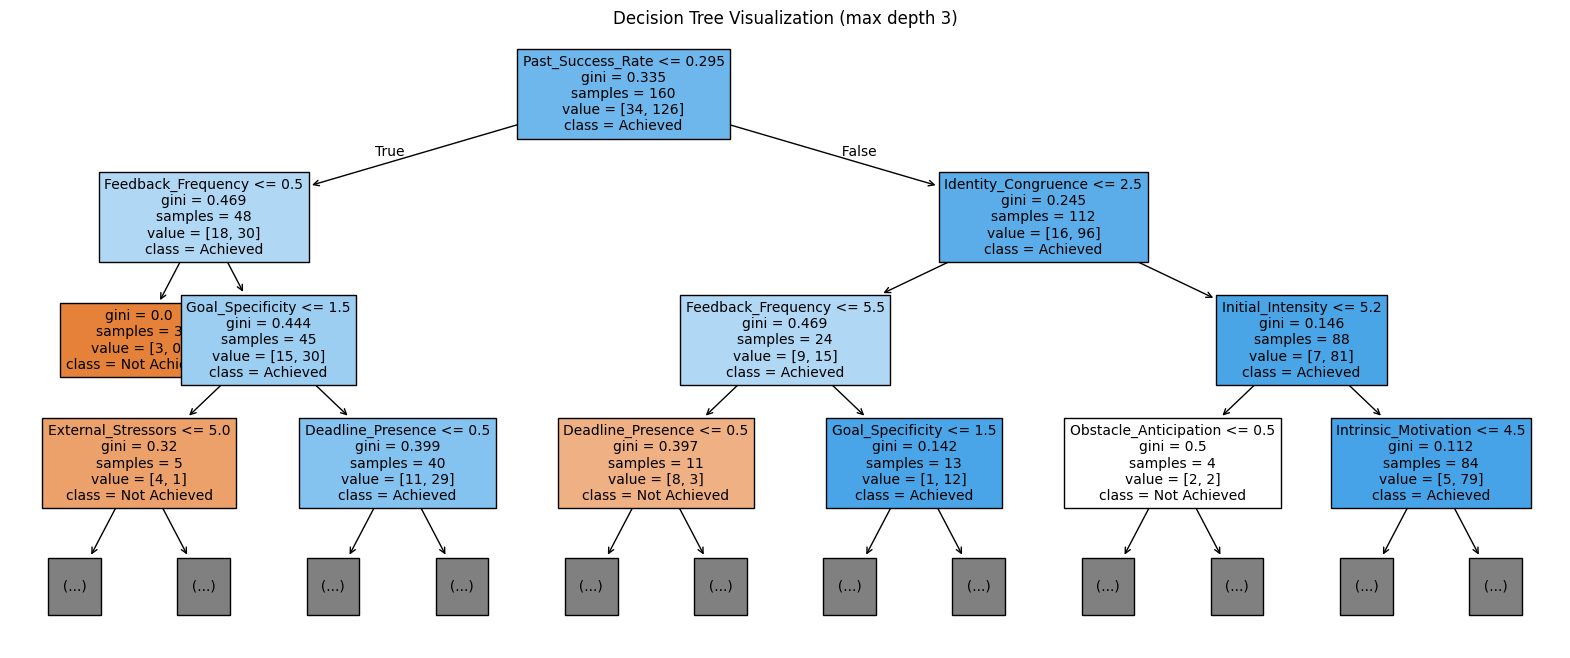

In [38]:
# Decision Tree visualization
plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=X.columns,
          class_names=['Not Achieved', 'Achieved'],
          filled=True, max_depth=3, fontsize=10)
plt.title("Decision Tree Visualization (max depth 3)")
plt.show()


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [41]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results:")
print(f"Accuracy : {acc_rf:.4f}")
print(f"ROC-AUC  : {roc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Achieved', 'Achieved']))

Random Forest Results:
Accuracy : 0.8000
ROC-AUC  : 0.7500

              precision    recall  f1-score   support

Not Achieved       0.50      0.12      0.20         8
    Achieved       0.82      0.97      0.89        32

    accuracy                           0.80        40
   macro avg       0.66      0.55      0.54        40
weighted avg       0.75      0.80      0.75        40



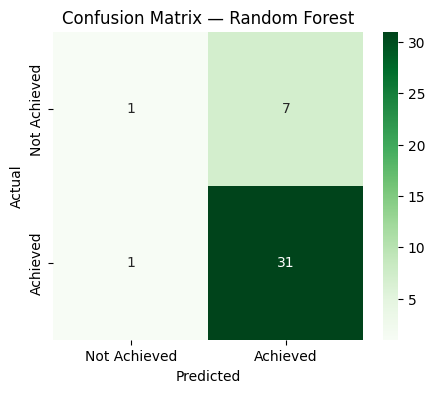

In [42]:
# Confusion matrix — Random Forest
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Greens', xticklabels=['Not Achieved', 'Achieved'],
            yticklabels=['Not Achieved', 'Achieved'])
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

In [43]:
comparison = {
    'Model'    : ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy' : [round(acc_lr,4), round(acc_dt,4), round(acc_rf,4)],
    'ROC-AUC'  : [round(roc_lr,4), round(roc_dt,4), round(roc_rf,4)],
}
comparison_df = pd.DataFrame(comparison)
print(comparison_df)

                 Model  Accuracy  ROC-AUC
0  Logistic Regression       0.8   0.7852
1        Decision Tree       0.8   0.5547
2        Random Forest       0.8   0.7500


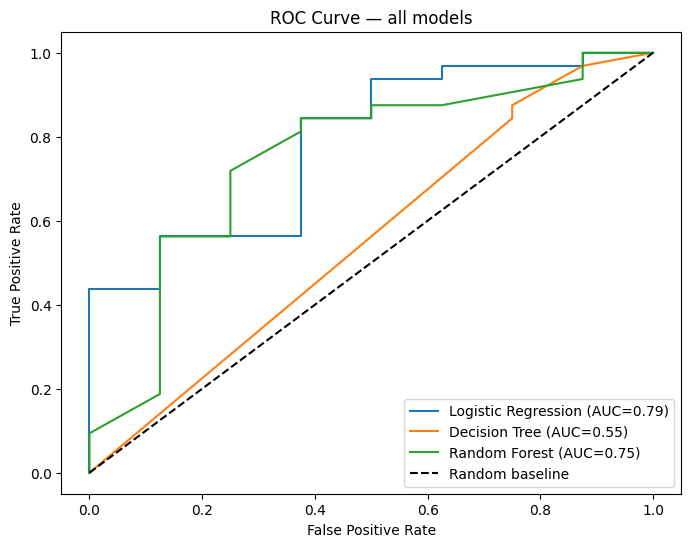

In [44]:
# ROC Curve — all three models
plt.figure(figsize=(8, 6))
for name, y_prob in [('Logistic Regression', y_prob_lr),
                       ('Decision Tree',      y_prob_dt),
                       ('Random Forest',       y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--', label='Random baseline')
plt.title("ROC Curve — all models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


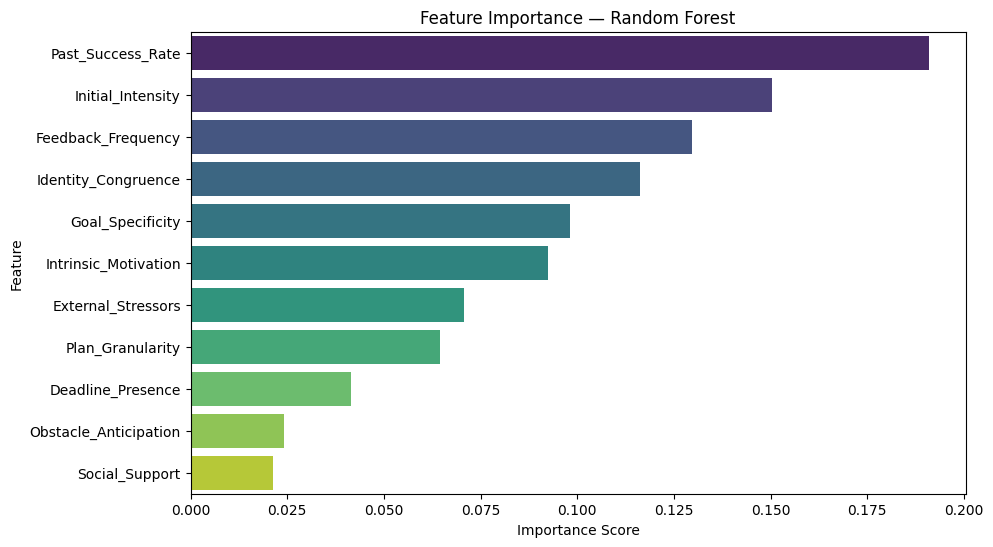

In [46]:
# Feature importance — Random Forest
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, hue=feat_importance.index, palette='viridis', legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

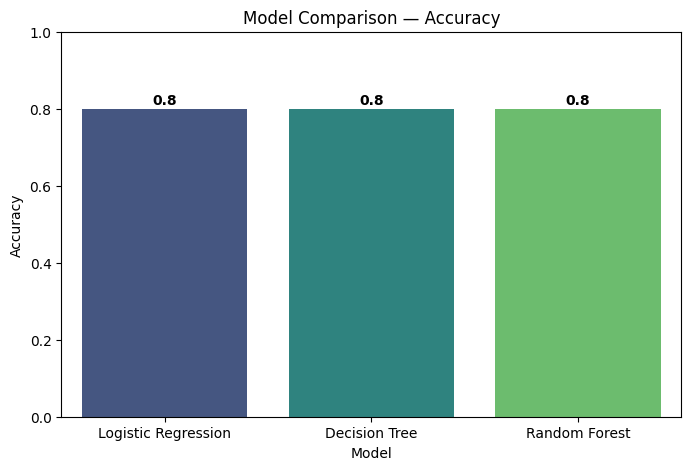

In [48]:
# Visual comparison — accuracy bar chart
models   = ['Logistic Regression', 'Decision Tree', 'Random Forest']
acc_vals = [round(acc_lr,4), round(acc_dt,4), round(acc_rf,4)]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=acc_vals, hue=models, palette='viridis', legend=False)
plt.title("Model Comparison — Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(acc_vals):
    plt.text(i, v + 0.01, str(v), ha='center', fontweight='bold')
plt.show()
